In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("malaychand/coco-25-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 185M/185M [00:01<00:00, 117MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1):
['classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'classification', 'test'))}")

Contents of the 'train' directory: ['couch', 'potted plant', 'stop sign', 'airplane', 'pizza', 'truck', 'traffic light', 'cow', 'bicycle', 'train', 'bottle', 'car', 'bird', 'motorcycle', 'bench', 'elephant', 'dog', 'cat', 'cake', 'chair', 'horse', 'cup', 'bus', 'bowl', 'person']
Contents of the 'test' directory: ['couch', 'potted plant', 'stop sign', 'airplane', 'pizza', 'truck', 'traffic light', 'cow', 'bicycle', 'train', 'bottle', 'car', 'bird', 'motorcycle', 'bench', 'elephant', 'dog', 'cat', 'cake', 'chair', 'horse', 'cup', 'bus', 'bowl', 'person']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train) ---
Found 5250 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/train. Displaying 6 samples:


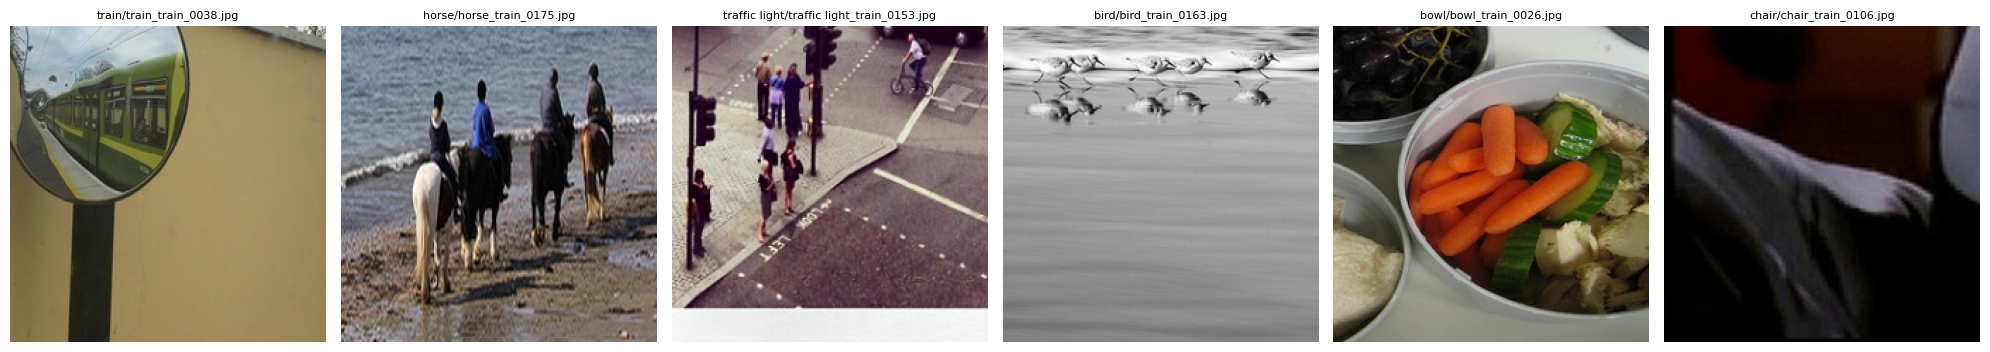


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test) ---
Found 750 images in /root/.cache/kagglehub/datasets/malaychand/coco-25-classification-dataset/versions/1/classification/test. Displaying 6 samples:


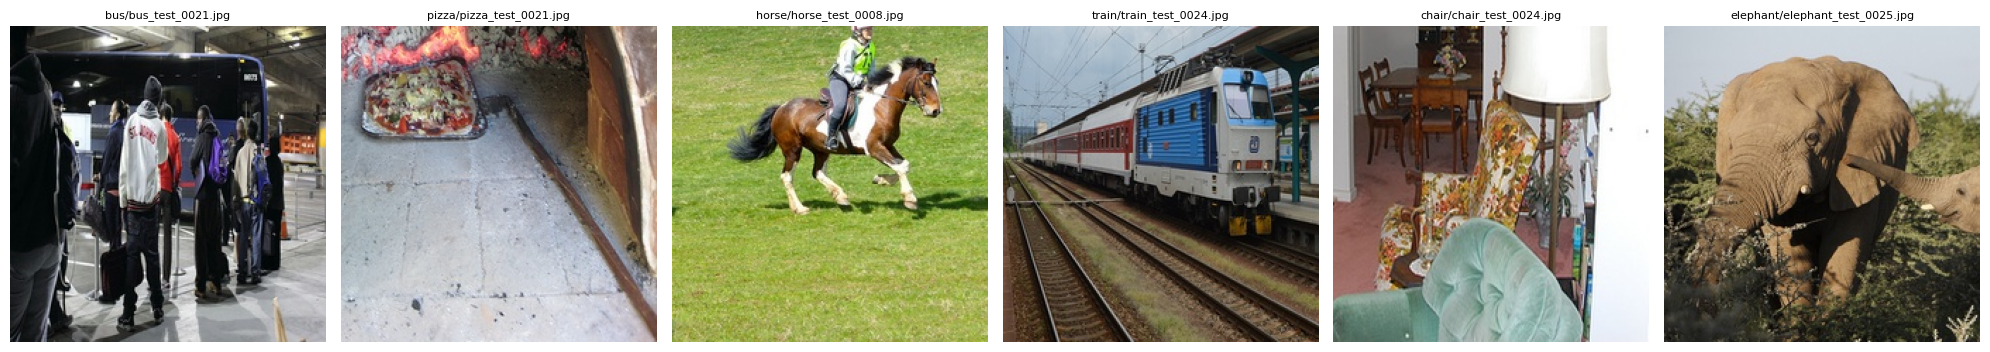

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'classification' subdirectory
train_path = os.path.join(path, 'classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
else:
    print('Note: Training on CPU might be slow.')

Using device: cuda
GPU Name: Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Set parameters
BATCH_SIZE = 32
NUM_CLASSES = 25
EPOCHS = 10
LEARNING_RATE = 0.001

# Data Augmentation and Normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Classes: {train_dataset.classes}')

Classes: ['airplane', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [ ]:
# Build DenseNet model
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Freeze parameters (Optional, depending on if you want fine-tuning)
# for param in model.parameters():
#     param.requires_grad = False

# Modify final fully connected layer
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, NUM_CLASSES)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("DenseNet model initialized and moved to GPU.")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 157MB/s]


DenseNet model initialized and moved to GPU.


In [ ]:
# Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(test_loader.dataset)
    val_epoch_acc = 100. * val_correct / val_total

    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f'Epoch {epoch+1}/{EPOCHS}: Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}% | Val Loss: {val_epoch_loss:.4f}, Acc: {val_epoch_acc:.2f}%')

Epoch 1/10: Train Loss: 1.8567, Acc: 45.05% | Val Loss: 1.4767, Acc: 55.73%
Epoch 2/10: Train Loss: 1.2444, Acc: 63.09% | Val Loss: 1.2764, Acc: 63.87%
Epoch 3/10: Train Loss: 0.9287, Acc: 72.70% | Val Loss: 1.4739, Acc: 59.07%
Epoch 4/10: Train Loss: 0.8527, Acc: 75.05% | Val Loss: 1.0637, Acc: 69.07%
Epoch 5/10: Train Loss: 0.6308, Acc: 80.72% | Val Loss: 0.9015, Acc: 76.80%
Epoch 6/10: Train Loss: 0.5077, Acc: 84.00% | Val Loss: 1.0975, Acc: 73.47%
Epoch 7/10: Train Loss: 0.3305, Acc: 90.02% | Val Loss: 0.9409, Acc: 74.13%
Epoch 8/10: Train Loss: 0.4269, Acc: 87.43% | Val Loss: 0.9700, Acc: 76.27%
Epoch 9/10: Train Loss: 0.3061, Acc: 90.34% | Val Loss: 1.1356, Acc: 72.67%
Epoch 10/10: Train Loss: 0.3167, Acc: 90.04% | Val Loss: 0.8941, Acc: 80.40%


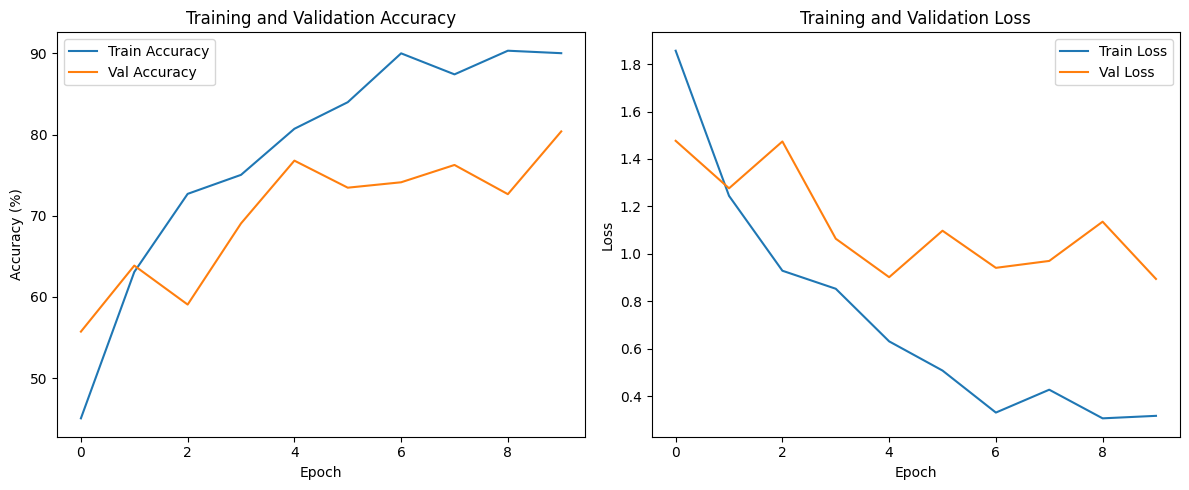

In [ ]:
import matplotlib.pyplot as plt

# Summarize results and plot
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()